In [1]:
!pip -q install xgboost scikit-learn pandas numpy matplotlib seaborn

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from xgboost import XGBClassifier

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train_path = "/content/KDDTest+.txt"
test_path  = "/content/KDDTrain+.txt"

if not os.path.exists(train_path) or not os.path.exists(test_path):
    raise FileNotFoundError("Please upload KDDTrain+.txt and KDDTest+.txt into /content")

train_df = pd.read_csv(train_path, names=columns)
test_df  = pd.read_csv(test_path, names=columns)

# Binary labels
train_df["target"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["target"]  = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

X_train = train_df.drop(columns=["label", "difficulty", "target"])
y_train = train_df["target"]

X_test = test_df.drop(columns=["label", "difficulty", "target"])
y_test = test_df["target"]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

# Optional: use this only for very fast testing/debugging
# X_train = X_train.sample(20000, random_state=42)
# y_train = y_train.loc[X_train.index]
# print("Reduced train shape for fast run:", X_train.shape)

Train shape: (22544, 41)
Test shape : (125973, 41)


In [4]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

feature_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=20
)

print("Preprocessing and feature selection ready.")

Preprocessing and feature selection ready.


In [5]:
base_models = [
    ("rf", RandomForestClassifier(
        n_estimators=60,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )),
    ("svm_fast", SGDClassifier(
        loss="hinge",   # linear SVM style
        max_iter=1000,
        tol=1e-3,
        random_state=42
    )),
    ("lr", LogisticRegression(
        max_iter=500,
        random_state=42
    ))
]

final_model = XGBClassifier(
    n_estimators=80,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=final_model,
    cv=3,
    n_jobs=-1,
    passthrough=False
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", feature_selector),
    ("classifier", stack_model)
])

print("Training started...")
model.fit(X_train, y_train)
print("Training completed.")

Training started...
Training completed.


Accuracy : 0.9192
Precision: 0.8961
Recall   : 0.9349
F1 Score : 0.9151

Classification Report:

              precision    recall  f1-score   support

      Normal       0.94      0.91      0.92     67343
      Attack       0.90      0.93      0.92     58630

    accuracy                           0.92    125973
   macro avg       0.92      0.92      0.92    125973
weighted avg       0.92      0.92      0.92    125973



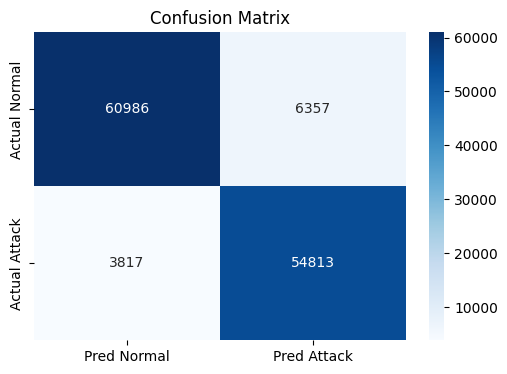


Sample Input:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,150,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0



Sample Output:
Prediction: Normal
Probability of Attack: 0.0556
Action: ALLOW


In [6]:
y_pred = model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Normal", "Pred Attack"],
            yticklabels=["Actual Normal", "Actual Attack"])
plt.title("Confusion Matrix")
plt.show()

def prevention_action(pred):
    return "ALLOW" if pred == 0 else "BLOCK + ALERT"

sample = X_test.iloc[[0]].copy()
pred = model.predict(sample)[0]

if hasattr(model, "predict_proba"):
    prob = model.predict_proba(sample)[0][1]
else:
    prob = None

print("\nSample Input:")
display(sample)

print("\nSample Output:")
print("Prediction:", "Normal" if pred == 0 else "Attack")
print("Probability of Attack:", round(float(prob), 4) if prob is not None else "N/A")
print("Action:", prevention_action(pred))

In [8]:
# -----------------------------
# USER INPUT (Manual Entry)
# -----------------------------

# Step 1: Base structure tiskovadam
manual_input = X_train.iloc[[0]].copy()

print("👉 Enter few values (remaining default ga untayi)")

# Step 2: User input
duration_input = input("Enter duration: ").strip()
manual_input["duration"] = int(duration_input) if duration_input else 0

src_bytes_input = input("Enter src_bytes: ").strip()
manual_input["src_bytes"] = int(src_bytes_input) if src_bytes_input else 0

dst_bytes_input = input("Enter dst_bytes: ").strip()
manual_input["dst_bytes"] = int(dst_bytes_input) if dst_bytes_input else 0

count_input = input("Enter count: ").strip()
manual_input["count"] = int(count_input) if count_input else 0

manual_input["protocol_type"] = input("Enter protocol (tcp/udp/icmp): ")
manual_input["service"] = input("Enter service (http/ftp/etc): ")
manual_input["flag"] = input("Enter flag (SF/REJ/etc): ")

# Step 3: Prediction
pred = model.predict(manual_input)[0]
prob = model.predict_proba(manual_input)[0][1]

# Step 4: Output
print("\n🔍 RESULT")
print("Prediction :", "Normal" if pred == 0 else "Attack")
print("Probability:", round(prob, 4))

if pred == 0:
    print("Action     : ALLOW ✅")
else:
    print("Action     : BLOCK 🚫 + ALERT ⚠️")

👉 Enter few values (remaining default ga untayi)
Enter duration: 0
Enter src_bytes: 11
Enter dst_bytes: 23
Enter count: 2
Enter protocol (tcp/udp/icmp): 1
Enter service (http/ftp/etc): 23
Enter flag (SF/REJ/etc): 44

🔍 RESULT
Prediction : Attack
Probability: 0.9977
Action     : BLOCK 🚫 + ALERT ⚠️
